# Window — Hinge Constraint Engine Demo

This notebook demonstrates the **deterministic constraint reasoning engine** for hinge-to-mounting-plate compatibility selection.

## The Problem

Selecting the right concealed hinge and mounting plate for a cabinet door is a genuine constraint satisfaction problem. A contractor needs to match:

- **Opening angle** (95°–170°) to the cabinet position (standard, corner, blind corner)
- **Overlay type** (full, half, inset) to the door/cabinet gap requirements
- **Mounting plate** that is series-compatible with the hinge and achieves the desired overlay
- **Weight capacity** sufficient for the door weight, distributed across the correct number of hinges
- **Door thickness** within the hinge's rated range, with enough material behind the cup bore
- **Boring pattern** matching the cabinet's pre-drilled holes (42mm, 45mm, or 48mm)
- **Mounting method** compatibility between hinge arm and plate (screw-on, dowel, euro screw, etc.)
- **Brand lock** — hinges and plates must be from the same manufacturer

Getting any of these wrong means a site visit wasted and a contractor who won't come back. Filter dropdowns can't capture these interdependencies. An LLM would guess. The constraint engine *proves* every recommendation is correct.

## How the Engine Works

The engine evaluates every hinge × plate combination against **14 constraint rules** and returns only provably valid configurations, ranked by price and capacity. Every evaluation produces a full rule trace — pass/fail for each rule, the values compared, and remediation suggestions for failures. This trace is what allows the conversational layer to explain *why* a recommendation was made.

The engine uses **indexed pre-filtering** on hinges (by brand, cabinet type, and application) to narrow candidates before the brute-force plate evaluation. At the current catalog size (53 hinges × 55 plates = 2,915 pairs × 14 rules), this completes in milliseconds.

**What's covered in this notebook:**
1. Catalog overview — what products are available across brands
2. Constraint rules — what the engine checks
3. Customer scenarios — five real-world selection problems
4. Constraint trace deep dive — how every rule is evaluated
5. Compatibility matrix — the full hinge × plate landscape
6. Price vs capacity analysis — trade-offs across valid configurations
7. Failure analysis — why some requirements can't be satisfied
8. Interactive explorer — test your own scenarios

In [ ]:
import json
import sys
from pathlib import Path
from IPython.display import display, Image, HTML

# Find project root (works regardless of kernel working directory)
_project_root = Path.cwd()
while _project_root != _project_root.parent:
    if (_project_root / "sample-data").exists() and (_project_root / "engine_v2").exists():
        break
    _project_root = _project_root.parent
sys.path.insert(0, str(_project_root))
DATA_DIR = _project_root / "sample-data"

from engine_v1 import (
    ConcealedHinge, MountingPlate, CustomerRequirements,
    HingeConstraintEngine, load_from_json,
    ApplicationType, CabinetType, CabinetPosition, RuleCategory,
)

# Load catalog data
data_dir = DATA_DIR
hinges, plates = load_from_json(data_dir)
engine = HingeConstraintEngine(hinges, plates)

# Load raw JSON for image references
with open(data_dir / "hinges.json") as f:
    hinges_raw = {h["sku"]: h for h in json.load(f)}
with open(data_dir / "mounting_plates.json") as f:
    plates_raw = {p["sku"]: p for p in json.load(f)}

def get_image_path(sku):
    """Get the absolute image path for a product SKU, or None."""
    entry = hinges_raw.get(sku) or plates_raw.get(sku)
    if entry and entry.get("image"):
        return data_dir / entry["image"]
    return None

def _img_data_uri(path):
    """Convert an image file to a base64 data URI for inline display."""
    import base64
    suffix = path.suffix.lower()
    mime = {"jpg": "image/jpeg", "jpeg": "image/jpeg", "png": "image/png", "gif": "image/gif"}.get(suffix.lstrip("."), "image/jpeg")
    b64 = base64.b64encode(path.read_bytes()).decode()
    return f"data:{mime};base64,{b64}"

def show_product_images(hinge_sku, plate_sku, width=200):
    """Display hinge and plate images side by side if available."""
    h_path = get_image_path(hinge_sku)
    p_path = get_image_path(plate_sku)
    html = '<div style="display:flex; gap:20px; align-items:flex-start; margin:10px 0;">'
    if h_path and h_path.exists():
        html += f'<div style="text-align:center"><img src="{_img_data_uri(h_path)}" width="{width}"><br><small>{hinge_sku}</small></div>'
    if p_path and p_path.exists():
        html += f'<div style="text-align:center"><img src="{_img_data_uri(p_path)}" width="{width}"><br><small>{plate_sku}</small></div>'
    html += '</div>'
    if h_path or p_path:
        display(HTML(html))

print(f"Loaded {len(hinges)} hinges and {len(plates)} mounting plates")
print(f"Using production engine (Pydantic models, indexed pre-filtering, no R010 derating)")

Loaded 53 hinges and 55 mounting plates
Using production engine (Pydantic models, indexed pre-filtering, no R010 derating)


## 1. Catalog Overview

The product catalog contains concealed European hinges and their compatible mounting plates from three manufacturers: **Blum** (Austrian, market leader), **Grass America** (Tiomos and Nexis series), and **Hafele** (Duomatic series).

Each hinge has physical specs (opening angle, cup diameter, boring pattern), a rated door thickness range, a maximum door weight capacity (manufacturer's published rating — no derating applied), and a mounting method. Each mounting plate has a series compatibility list, a plate height that determines achievable overlay, and a mounting method that must be compatible with the hinge.

The engine loads these from JSON via `loader.py`, which converts the flat catalog format into typed Pydantic models with enum validation.

In [ ]:
# Hinge catalog summary
print("=" * 80)
print("HINGE CATALOG")
print("=" * 80)
print(f"{'SKU':<22} {'Brand':<8} {'Series':<20} {'App':<14} {'Angle':>5}  {'Weight':>6}  {'SC':>3}  {'Price':>7}")
print("-" * 80)
for h in hinges:
    sc = "Yes" if h.soft_close else "No"
    price = f"${h.price_usd:>5.2f}" if h.price_usd is not None else "   N/A"
    print(f"{h.sku:<22} {h.brand:<8} {h.series.value:<20} {h.application.value:<14} {h.opening_angle_deg:>4}\u00b0  {h.max_door_weight_kg:>5.1f}kg  {sc:>3}  {price:>7}")

HINGE CATALOG
SKU                    Brand    Series               App            Angle  Weight   SC    Price
--------------------------------------------------------------------------------
BLM-71B3550            Blum     CLIP top BLUMOTION   full_overlay    110°    7.5kg  Yes   $ 4.85
BLM-71B3650            Blum     CLIP top BLUMOTION   half_overlay    110°    7.5kg  Yes   $ 4.85
BLM-71B3750            Blum     CLIP top BLUMOTION   inset           110°    5.0kg  Yes   $ 5.20
BLM-71B3580            Blum     CLIP top BLUMOTION   full_overlay    110°    7.5kg  Yes   $ 4.85
BLM-71T3550            Blum     CLIP top             full_overlay    110°    7.5kg   No   $ 3.10
BLM-71T3650            Blum     CLIP top             half_overlay    110°    7.5kg   No   $ 3.10
BLM-71T3750            Blum     CLIP top             inset           110°    5.0kg   No   $ 3.10
BLM-73B3550            Blum     CLIP top BLUMOTION   full_overlay    110°    7.5kg  Yes      N/A
BLM-71T5550            Blum     C

In [ ]:
# Mounting plate catalog summary
print("=" * 80)
print("MOUNTING PLATE CATALOG")
print("=" * 80)
print(f"{'SKU':<22} {'Brand':<8} {'Series':<10} {'Type':<14} {'Mount':<14} {'Cabinet':<12} {'Price':>7}")
print("-" * 80)
for p in plates:
    price = f"${p.price_usd:>5.2f}" if p.price_usd is not None else "   N/A"
    print(f"{p.sku:<22} {p.brand:<8} {p.series:<10} {p.plate_type.value:<14} {p.mounting_method.value:<14} {p.cabinet_type.value:<12} {price:>7}")

MOUNTING PLATE CATALOG
SKU                    Brand    Series     Type           Mount          Cabinet        Price
--------------------------------------------------------------------------------
BLM-173L6100           Blum     CLIP       cruciform      screw_on       frameless     $ 1.20
BLM-173L6130           Blum     CLIP       cruciform      screw_on       frameless     $ 1.20
BLM-173L8100           Blum     CLIP       cruciform      system_screw   frameless        N/A
BLM-173L8130           Blum     CLIP       cruciform      system_screw   frameless        N/A
BLM-173H7100           Blum     CLIP       wing_cam       screw_on       frameless        N/A
BLM-173H7130           Blum     CLIP       wing_cam       screw_on       frameless        N/A
BLM-175H7100           Blum     CLIP       wing           screw_on       frameless     $ 0.85
BLM-175H7130           Blum     CLIP       wing           screw_on       frameless        N/A
BLM-175H7190           Blum     CLIP       wing   

In [ ]:
# Brand and application distribution
from collections import Counter

brand_counts = Counter(h.brand for h in hinges)
app_counts = Counter(h.application.value for h in hinges)
angle_counts = Counter(h.opening_angle_deg for h in hinges)

print("Hinges by brand:", dict(brand_counts))
print("Hinges by application:", dict(app_counts))
print("Hinges by opening angle:", dict(angle_counts))
print()
print("Plates by brand:", dict(Counter(p.brand for p in plates)))
print("Plates by type:", dict(Counter(p.plate_type.value for p in plates)))

Hinges by brand: {'Blum': 25, 'Grass': 26, 'Hafele': 2}
Hinges by application: {'full_overlay': 27, 'half_overlay': 16, 'inset': 7, 'overlay': 3}
Hinges by opening angle: {110: 19, 120: 5, 155: 7, 125: 4, 95: 7, 170: 6, 107: 1, 100: 4}

Plates by brand: {'Blum': 20, 'Grass': 33, 'Hafele': 2}
Plates by type: {'cruciform': 11, 'wing_cam': 8, 'wing': 6, 'inline': 2, 'face_frame': 4, 'face_frame_adapter': 8, 'thick_wing': 4, 'face_frame_inset': 2, 'cam_baseplate': 7, 'two_piece': 3}


### Product Gallery

Reference photos for hinges and mounting plates in the catalog. These images were sourced from manufacturer websites and Wurth Baer product listings. Products with missing images (Hafele Duomatic, Grass Nexis, some Blum specialty plates) are not yet available — Hafele data came from web scraping rather than catalog extraction, and some plate variants weren't photographed in the source material.


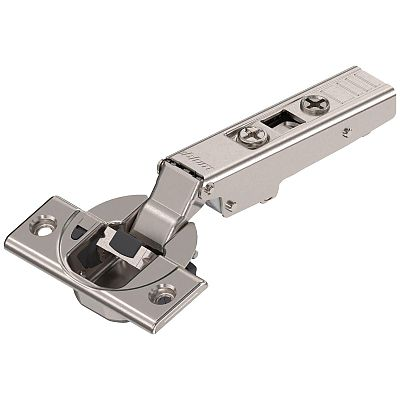
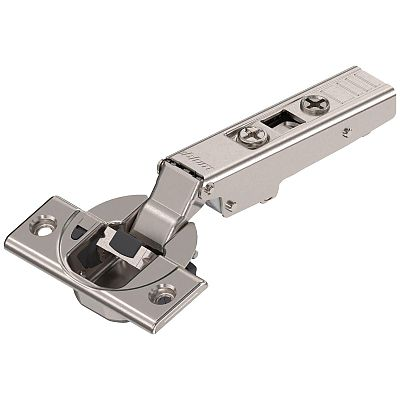
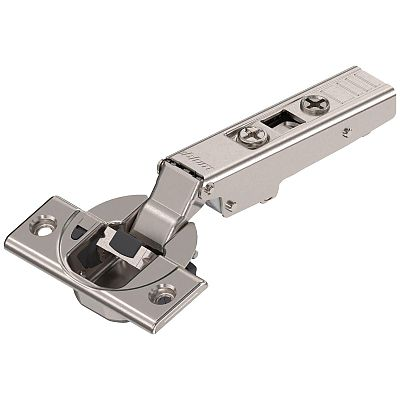
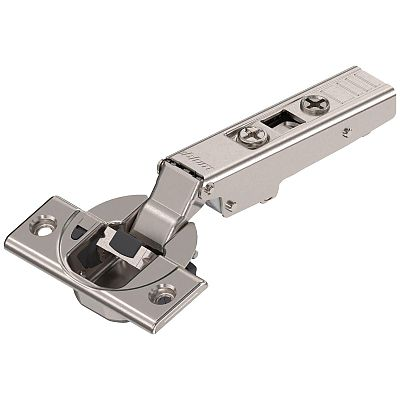
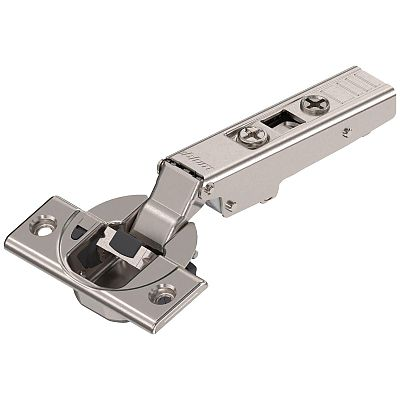
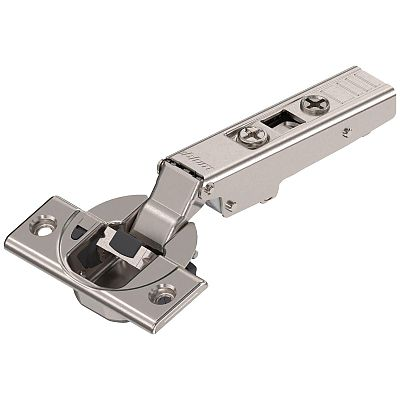
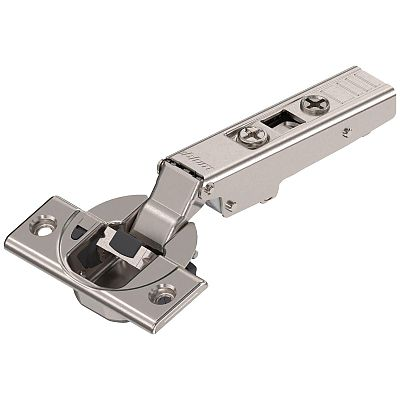
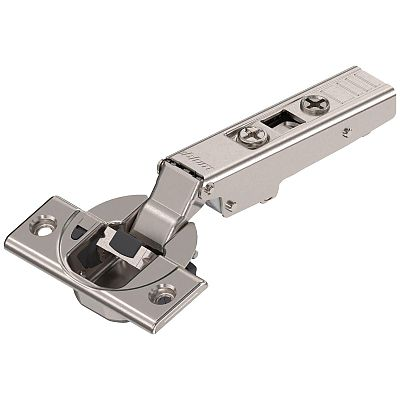
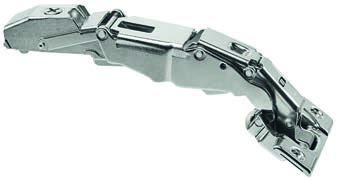
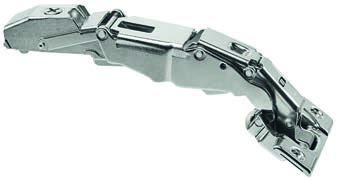
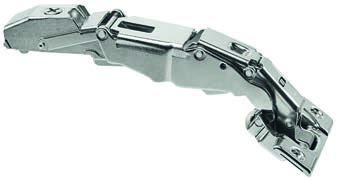
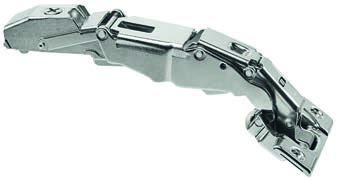
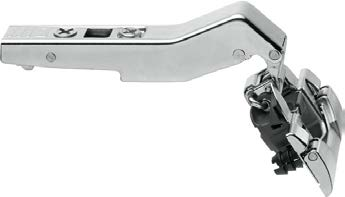
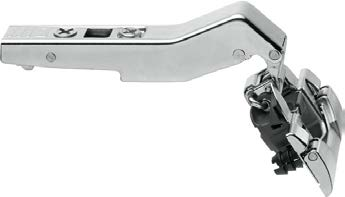
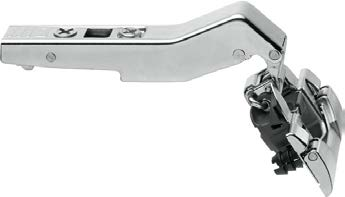
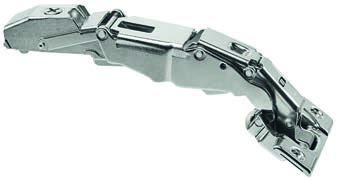
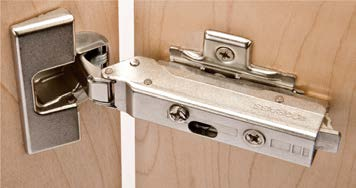
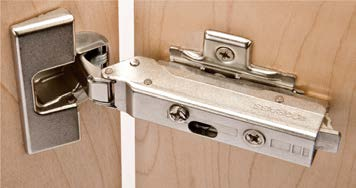
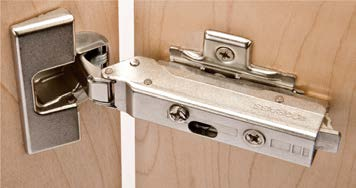
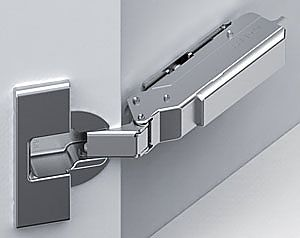
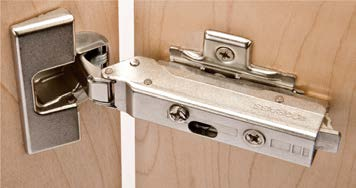
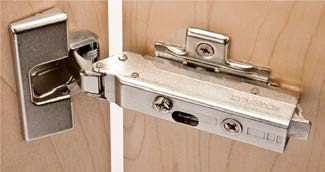
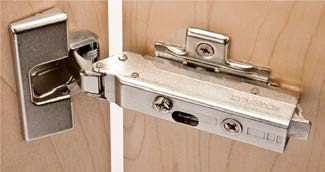
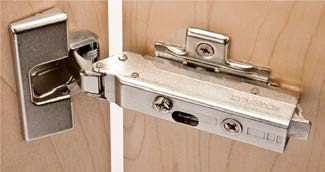
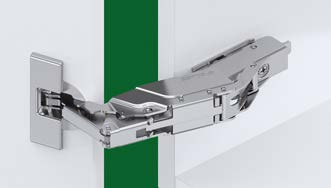
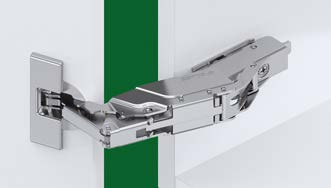
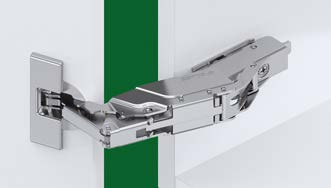
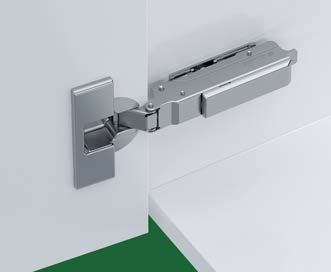
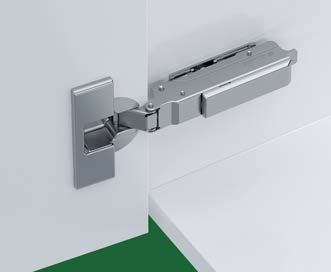
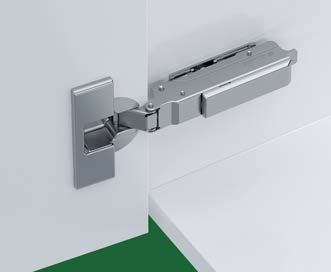
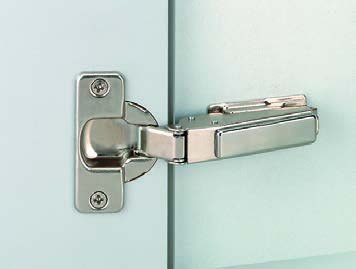
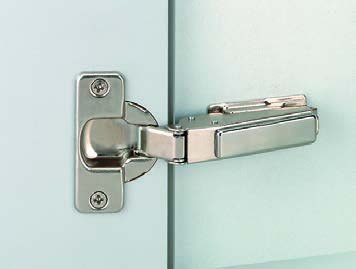
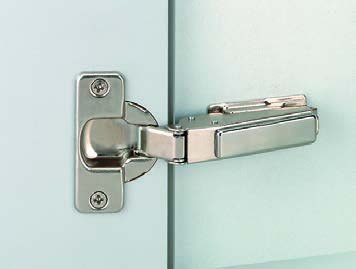
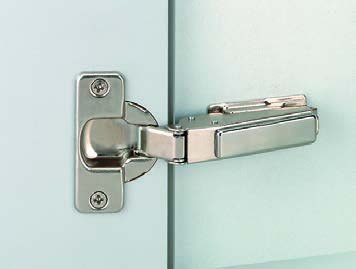
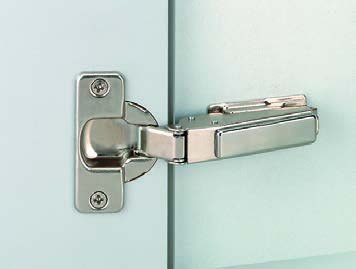
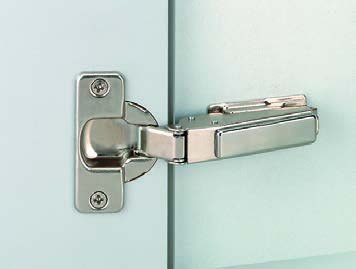
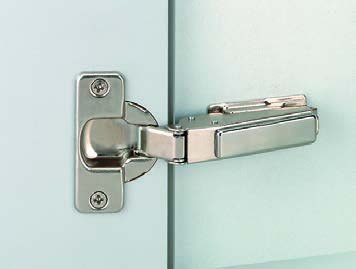
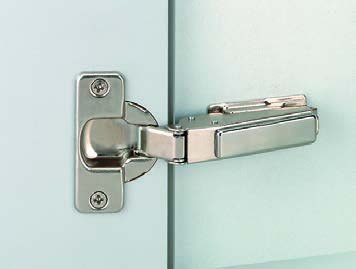
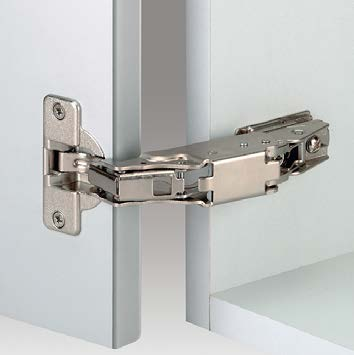
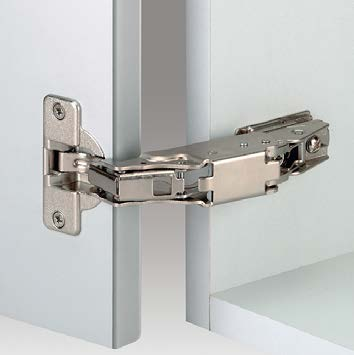
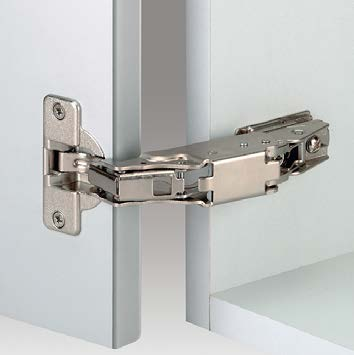
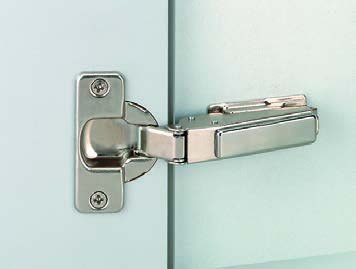
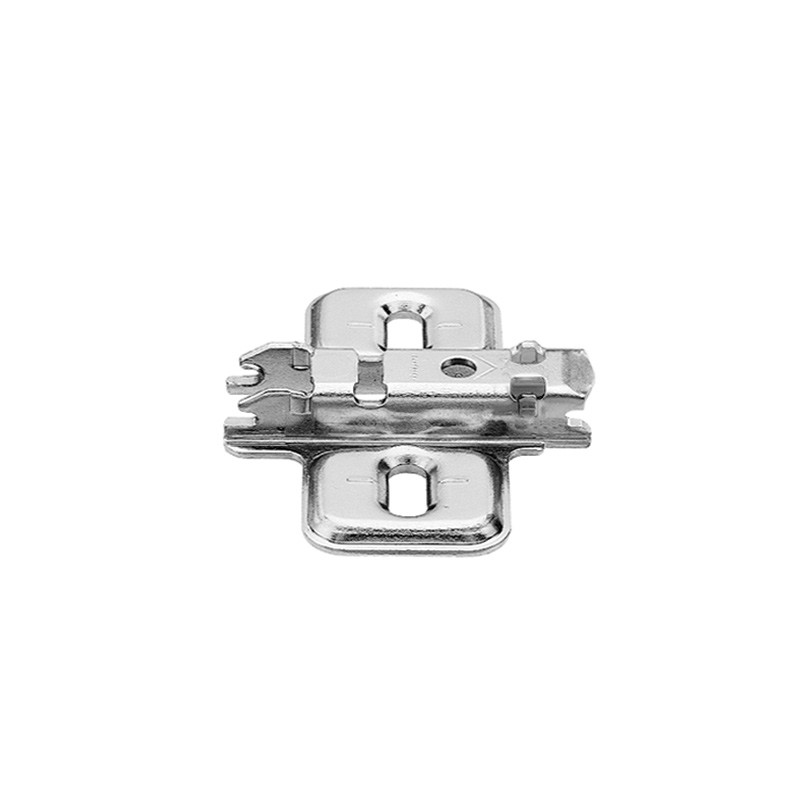
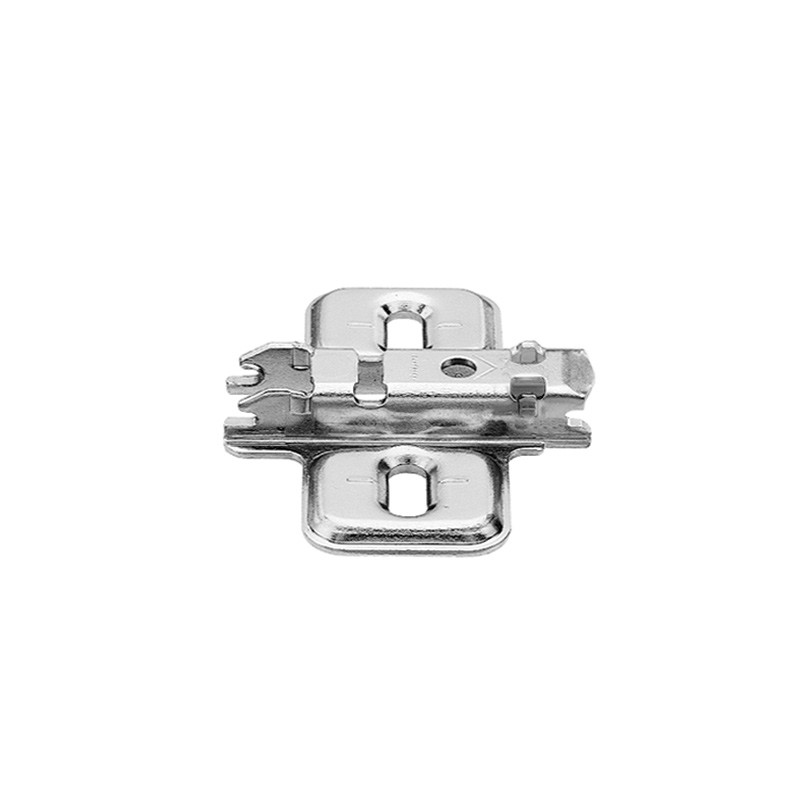
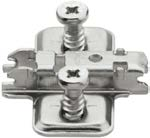
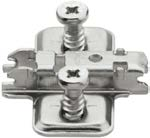
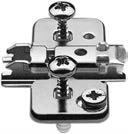
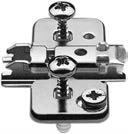
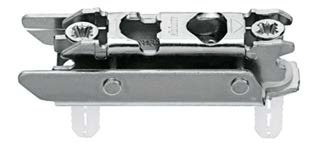
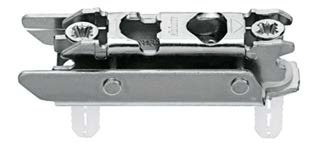
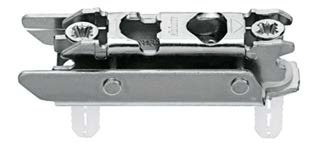
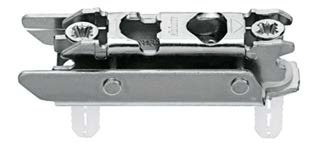
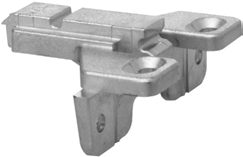
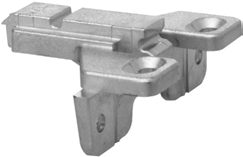
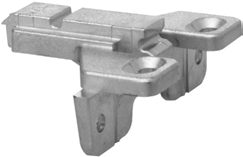
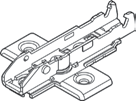
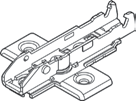
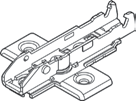
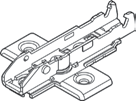
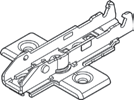
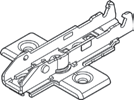
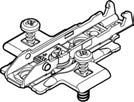
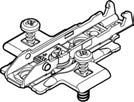
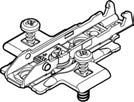
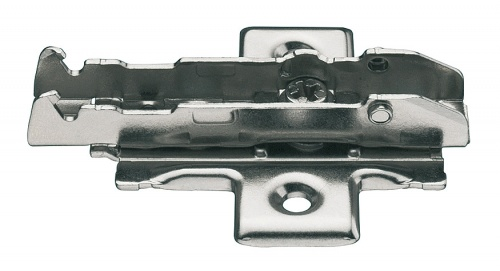
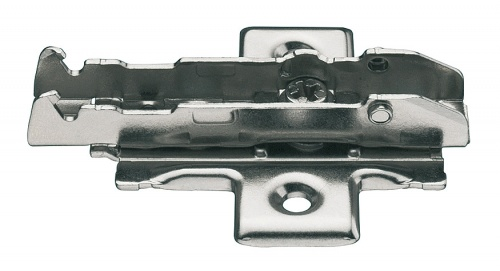
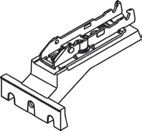
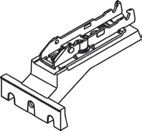
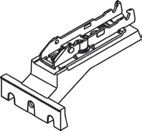
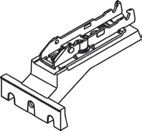

In [ ]:
# Display all products that have images
html = '<div style="display:flex; flex-wrap:wrap; gap:24px;">'

for sku, entry in {**hinges_raw, **plates_raw}.items():
    img = entry.get("image")
    if not img:
        continue
    img_path = data_dir / img
    if not img_path.exists():
        continue
    label = f"{entry['brand']} {entry.get('series', '')}"
    kind = "Hinge" if sku in hinges_raw else "Plate"
    html += f'''<div style="text-align:center; max-width:180px;">
        <img src="{_img_data_uri(img_path)}" width="160" style="border:1px solid #ddd; border-radius:4px; padding:4px;">
        <br><small><b>{sku}</b><br>{label}<br><i>{kind}</i></small>
    </div>'''

html += '</div>'
display(HTML(html))

## 2. Constraint Rules

The engine enforces **14 constraint rules** defined in `engine/rules.py` — the single source of truth. Rules are standalone Python functions with a common signature: `(hinge, plate, requirements, num_hinges) -> RuleResult`. The solver iterates a `RULES` list and calls each one — it doesn't know what rules exist or what they check.

Rules fall into three categories:

- **Hard constraints** (13 rules) — must all pass for a configuration to be valid. Cover brand lock, series compatibility, cabinet type, overlay range, inset support, door thickness, weight capacity, boring pattern, face frame overlay, adjacent door clearance, corner cabinet angle, mounting method, and cup depth.
- **Derived values** (1 rule) — hinge count computed from door height (2–5 hinges based on height thresholds).
- **Preferences** (1 rule) — soft-close preference. Non-blocking: a hinge without soft-close can still be recommended if the customer didn't request it.

Each rule returns a `RuleResult` with the rule ID, category, pass/fail, a human-readable detail string, the values that were compared, and a remediation suggestion if it failed.

In [ ]:
# Display constraint rules — evaluate a dummy pair to extract rule metadata
dummy_config = engine.evaluate(hinges[0], plates[0], CustomerRequirements(
    cabinet_type=CabinetType.FRAMELESS, door_thickness_mm=19, door_height_mm=720,
    door_weight_kg=5.0, application=ApplicationType.FULL_OVERLAY, desired_overlay_mm=16,
    boring_pattern_mm=45, soft_close=False,
))

print(f"{'ID':<6} {'Name':<30} {'Category':<18}")
print("-" * 54)
for r in dummy_config.rule_results:
    print(f"{r.rule_id:<6} {r.rule_name:<30} {r.category.value:<18}")

ID     Name                           Category          
------------------------------------------------------
R001   brand_lock                     hard_constraint   
R002   series_compatibility           hard_constraint   
R003   cabinet_type_match             hard_constraint   
R004   overlay_in_range               hard_constraint   
R005   inset_support                  hard_constraint   
R006   door_thickness_range           hard_constraint   
R007   door_weight_limit              hard_constraint   
R009   boring_pattern_match           hard_constraint   
R013   corner_cabinet_angle           hard_constraint   
R012   adjacent_door_clearance        hard_constraint   
R011   face_frame_overlay             hard_constraint   
R014   mounting_method_match          hard_constraint   
R015   cup_depth_door_thickness       hard_constraint   
PREF   soft_close_preference          preference        


## 3. Customer Scenarios

Five scenarios that exercise different parts of the constraint space:

1. **Standard kitchen remodel** — Blum preference, full overlay, soft-close. The most common case: should find multiple valid configurations and rank by price.
2. **Corner cabinet** — No brand preference. Corner cabinets require a wide-angle hinge (>=155°), which limits options significantly. Tests R013 (corner cabinet angle).
3. **Tall pantry door** — 1600mm height, 14kg, Grass preferred. Tall doors need more hinges (R008: 4 hinges for 1600mm). The weight check (R007) uses capacity × hinge count.
4. **Adjacent doors on shared partition** — Half overlay, 6mm per side. Tests R012 (combined overlay must fit within the 19mm partition).
5. **Constraint violation** — Heavy 12kg door on a corner cabinet, Blum only. Should fail: corner needs >=155° (R013), but the 155° Blum hinge only supports 5kg × 2 = 10kg capacity (R007). Demonstrates the engine's failure analysis with closest-match identification.

The engine's `solve_with_explanation()` API returns structured results with three possible statuses:
- `"solved"` — valid configurations found, ranked by price then capacity
- `"no_solution_for_brand"` — no solution for the preferred brand, but alternatives exist from other brands
- `"no_solution"` — no valid configuration exists; returns the closest match and its failed rules

  Scenario 1: Standard kitchen — Blum, full overlay, soft-close
  Status: solved
  Found 81 valid configuration(s).

  Recommended: BLM-71B3550 + BLM-175H7100
    Blum CLIP top BLUMOTION 110° full_overlay
    Hinges/door: 2  |  Capacity: 15.0kg  |  Price: $11.4/door



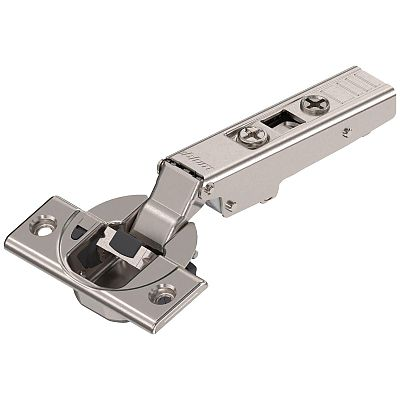

    + 3 alternative(s)

  Scenario 2: Corner cabinet — needs wide-angle hinge
  Status: solved
  Found 43 valid configuration(s).

  Recommended: BLM-71B7550 + BLM-175H7100
    Blum CLIP top BLUMOTION 155° full_overlay
    Hinges/door: 2  |  Capacity: 10.0kg  |  Price: $26.5/door



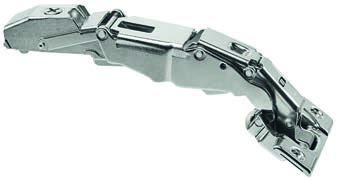

    + 3 alternative(s)

  Scenario 3: Tall pantry door — 1600mm, heavy, Grass preferred
  Status: solved
  Found 40 valid configuration(s).

  Recommended: GRS-F028138519 + GRS-F058139761
    Grass Tiomos 110° full_overlay
    Hinges/door: 4  |  Capacity: 36.0kg  |  Price: $28.4/door



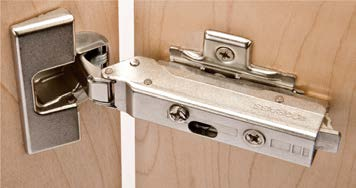
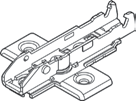

    + 3 alternative(s)

  Scenario 4: Adjacent doors sharing partition — half overlay
  Status: solved
  Found 33 valid configuration(s).

  Recommended: BLM-71B3650 + BLM-175H7100
    Blum CLIP top BLUMOTION 110° half_overlay
    Hinges/door: 2  |  Capacity: 15.0kg  |  Price: $11.4/door



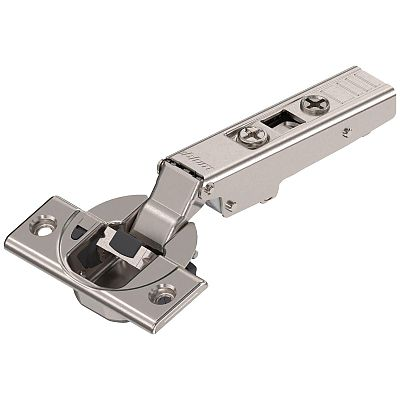

    + 3 alternative(s)

  Scenario 5: CONSTRAINT VIOLATION — heavy corner door
  Status: solved
  Found 33 valid configuration(s).

  Recommended: BLM-71B7550 + BLM-175H7100
    Blum CLIP top BLUMOTION 155° full_overlay
    Hinges/door: 3  |  Capacity: 15.0kg  |  Price: $39.75/door



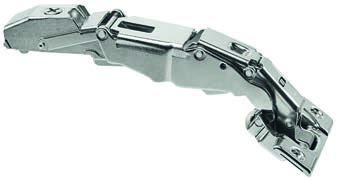

    + 3 alternative(s)



In [ ]:
scenarios = [
    (
        "Scenario 1: Standard kitchen — Blum, full overlay, soft-close",
        CustomerRequirements(
            cabinet_type=CabinetType.FRAMELESS, door_thickness_mm=19, door_height_mm=720,
            door_weight_kg=5.2, application=ApplicationType.FULL_OVERLAY, desired_overlay_mm=16,
            boring_pattern_mm=45, soft_close=True, preferred_brand="Blum",
        ),
    ),
    (
        "Scenario 2: Corner cabinet — needs wide-angle hinge",
        CustomerRequirements(
            cabinet_type=CabinetType.FRAMELESS, door_thickness_mm=19, door_height_mm=800,
            door_weight_kg=4.0, application=ApplicationType.FULL_OVERLAY, desired_overlay_mm=16,
            boring_pattern_mm=45, soft_close=True, cabinet_position=CabinetPosition.CORNER,
        ),
    ),
    (
        "Scenario 3: Tall pantry door — 1600mm, heavy, Grass preferred",
        CustomerRequirements(
            cabinet_type=CabinetType.FRAMELESS, door_thickness_mm=22, door_height_mm=1600,
            door_weight_kg=14.0, application=ApplicationType.FULL_OVERLAY, desired_overlay_mm=16,
            boring_pattern_mm=45, soft_close=True, preferred_brand="Grass",
        ),
    ),
    (
        "Scenario 4: Adjacent doors sharing partition — half overlay",
        CustomerRequirements(
            cabinet_type=CabinetType.FRAMELESS, door_thickness_mm=19, door_height_mm=720,
            door_weight_kg=4.0, application=ApplicationType.HALF_OVERLAY, desired_overlay_mm=6,
            boring_pattern_mm=45, soft_close=True, preferred_brand="Blum",
            has_adjacent_door=True, adjacent_door_overlay_mm=6,
            partition_thickness_mm=19,
        ),
    ),
    (
        "Scenario 5: CONSTRAINT VIOLATION — heavy corner door",
        CustomerRequirements(
            cabinet_type=CabinetType.FRAMELESS, door_thickness_mm=22, door_height_mm=900,
            door_weight_kg=12.0, application=ApplicationType.FULL_OVERLAY, desired_overlay_mm=16,
            boring_pattern_mm=45, soft_close=True, cabinet_position=CabinetPosition.CORNER,
            preferred_brand="Blum",
        ),
    ),
]

# Store results for later analysis
all_results = []

for title, req in scenarios:
    result = engine.solve_with_explanation(req)
    all_results.append((title, req, result))
    
    print("=" * 75)
    print(f"  {title}")
    print(f"  Status: {result['status']}")
    print(f"  {result['message']}")
    
    if result["status"] == "solved":
        rec = result["recommended"]
        print(f"\n  Recommended: {rec['hinge']['sku']} + {rec['mounting_plate']['sku']}")
        print(f"    {rec['hinge']['description']}")
        price = f"${rec['total_price_per_door_usd']}" if rec['total_price_per_door_usd'] is not None else "N/A"
        print(f"    Hinges/door: {rec['hinges_per_door']}  |  Capacity: {rec['total_weight_capacity_kg']}kg  |  Price: {price}/door")
        show_product_images(rec['hinge']['sku'], rec['mounting_plate']['sku'])
        if result["alternatives"]:
            print(f"    + {len(result['alternatives'])} alternative(s)")
    
    elif result["status"] == "no_solution":
        print(f"\n  Failed rules:")
        for fr in result["failed_rules"]:
            print(f"    [{fr['rule']}] {fr['name']}: {fr['detail']}")
    
    elif result["status"] == "no_solution_for_brand":
        print(f"\n  Alternatives from other brands:")
        for alt in result["alternatives"]:
            price = f"${alt['total_price_per_door_usd']}" if alt['total_price_per_door_usd'] is not None else "N/A"
            print(f"    {alt['hinge']['sku']} — {price}/door")
            show_product_images(alt['hinge']['sku'], alt['mounting_plate']['sku'], width=150)
    
    print()

## 4. Constraint Trace Deep Dive

Every configuration carries its full rule trace — the pass/fail result for each of the 14 rules, with the exact values compared. This is the core of the engine's explainability: the conversational layer can tell a contractor not just *what* to buy, but *why* it's the right choice and *why* alternatives were rejected.

The trace below shows Scenario 1's recommended configuration. Every rule passes — that's what makes it a valid configuration. Note how conditional rules (R013 corner angle, R012 adjacent clearance, R011 face frame) are marked "skipped" when their precondition doesn't apply.

In [ ]:
# Full constraint trace for Scenario 1's recommended configuration
title, req, result = all_results[0]
print(f"{title}\n")

if result["status"] == "solved":
    trace = result["recommended"]["constraint_trace"]
    print(f"{'Rule':<6} {'Name':<28} {'Result':<6} Detail")
    print("-" * 90)
    for rule in trace:
        icon = "PASS" if rule["passed"] else "FAIL"
        print(f"{rule['rule']:<6} {rule['name']:<28} {icon:<6} {rule['detail']}")

Scenario 1: Standard kitchen — Blum, full overlay, soft-close

Rule   Name                         Result Detail
------------------------------------------------------------------------------------------
R001   brand_lock                   PASS   Hinge brand 'Blum' == plate brand 'Blum'
R002   series_compatibility         PASS   Hinge series 'CLIP top BLUMOTION' in plate compatible series ['CLIP top', 'CLIP top BLUMOTION', 'CLIP']
R003   cabinet_type_match           PASS   Cabinet type: hinge=frameless, plate=frameless, required=frameless
R004   overlay_in_range             PASS   Desired overlay 16.0mm vs plate range [14.0-20.0]mm for full_overlay
R005   inset_support                PASS   Not an inset application — skipped
R006   door_thickness_range         PASS   Door 19.0mm vs hinge range [16.0-26.0]mm
R007   door_weight_limit            PASS   Door 5.2kg vs capacity 7.5kg x 2 = 15.0kg
R009   boring_pattern_match         PASS   Hinge boring 45mm vs required 45mm
R013   corner_cabi

## 5. Compatibility Matrix

The constraint engine evaluates all 2,915 hinge × plate pairs exhaustively. The matrix below shows how many of the 14 rules each pair passes for a standard full-overlay frameless requirement.

Most pairs fail early — R001 (brand lock) eliminates all cross-brand combinations immediately, and R002 (series compatibility) eliminates most same-brand but wrong-series pairings. Only a small fraction of the matrix shows "ALL" (all rules passed). This is why the problem can't be solved with simple filter dropdowns — the valid region of the constraint space is sparse and shaped by the interaction of multiple rules.

In [ ]:
# Build a compatibility matrix: for a "standard" set of requirements,
# how many rules does each hinge+plate pair pass?
baseline_req = CustomerRequirements(
    cabinet_type=CabinetType.FRAMELESS, door_thickness_mm=19, door_height_mm=720,
    door_weight_kg=5.0, application=ApplicationType.FULL_OVERLAY, desired_overlay_mm=16,
    boring_pattern_mm=45, soft_close=False,
)

num_rules = len(engine.evaluate(hinges[0], plates[0], baseline_req).rule_results)

matrix = []
for h in hinges:
    row = []
    for p in plates:
        config = engine.evaluate(h, p, baseline_req)
        passed = sum(1 for r in config.rule_results if r.passed)
        row.append(passed)
    matrix.append(row)

# --- Summary statistics ---
from collections import Counter

all_scores = [score for row in matrix for score in row]
score_dist = Counter(all_scores)
total_pairs = len(hinges) * len(plates)
all_pass = sum(1 for s in all_scores if s == num_rules)

print(f"COMPATIBILITY MATRIX — {len(hinges)} hinges x {len(plates)} plates = {total_pairs:,} pairs")
print(f"Baseline: full overlay, frameless, 19mm door, 5kg, 45mm boring\n")

print(f"{'Rules passed':<14} {'Pairs':>6} {'%':>7}")
print("-" * 28)
for score in sorted(score_dist.keys()):
    count = score_dist[score]
    label = f"{score}/{num_rules}" if score < num_rules else f"ALL ({num_rules})"
    print(f"{label:<14} {count:>6} {count/total_pairs*100:>6.1f}%")
print(f"{'Total':<14} {total_pairs:>6}")

print(f"\nValid configurations (all rules pass): {all_pass} ({all_pass/total_pairs*100:.1f}%)")
print(f"The constraint space is sparse — {total_pairs - all_pass} of {total_pairs} pairs fail at least one rule.")

# --- Per-brand breakdown ---
print(f"\n{'Brand':<8} {'Hinges':>7} {'Plates':>7} {'Pairs':>7} {'Valid':>6} {'Valid %':>8}")
print("-" * 45)
for brand in sorted(set(h.brand for h in hinges)):
    brand_hinges = [i for i, h in enumerate(hinges) if h.brand == brand]
    brand_plates = [j for j, p in enumerate(plates) if p.brand == brand]
    brand_pairs = len(brand_hinges) * len(brand_plates)
    brand_valid = sum(1 for i in brand_hinges for j in brand_plates if matrix[i][j] == num_rules)
    pct = f"{brand_valid/brand_pairs*100:.1f}%" if brand_pairs > 0 else "N/A"
    print(f"{brand:<8} {len(brand_hinges):>7} {len(brand_plates):>7} {brand_pairs:>7} {brand_valid:>6} {pct:>8}")

# --- Where do failures concentrate? ---
print(f"\nFAILURE ANALYSIS — which rule scores are most common?")
print(f"Most pairs fail at score 1-2/{num_rules} (brand lock + series mismatch).")
low_score = sum(1 for s in all_scores if s <= 2)
print(f"Pairs scoring <= 2/{num_rules}: {low_score} ({low_score/total_pairs*100:.0f}%) — cross-brand pairs eliminated by R001/R002")

COMPATIBILITY MATRIX — 53 hinges x 55 plates = 2,915 pairs
Baseline: full overlay, frameless, 19mm door, 5kg, 45mm boring

Rules passed    Pairs       %
----------------------------
7/14               14    0.5%
8/14               61    2.1%
9/14              321   11.0%
10/14             165    5.7%
11/14             678   23.3%
12/14             913   31.3%
13/14             341   11.7%
ALL (14)          422   14.5%
Total            2915

Valid configurations (all rules pass): 422 (14.5%)
The constraint space is sparse — 2493 of 2915 pairs fail at least one rule.

Brand     Hinges  Plates   Pairs  Valid  Valid %
---------------------------------------------
Blum          25      20     500    257    51.4%
Grass         26      33     858    161    18.8%
Hafele         2       2       4      4   100.0%

FAILURE ANALYSIS — which rule scores are most common?
Most pairs fail at score 1-2/14 (brand lock + series mismatch).
Pairs scoring <= 2/14: 0 (0%) — cross-brand pairs eliminated by R0

## 6. Price vs Capacity Analysis

For a given set of requirements, multiple hinge + plate combinations may be valid. The engine ranks them by price ascending, then weight capacity descending — cheapest first, with ties broken by the configuration that handles the heaviest doors.

This section shows all valid configurations for a standard full-overlay frameless requirement with no brand preference. Note the price variation across brands and the capacity differences — a contractor might choose a more expensive hinge if they need the extra weight headroom for a solid wood door.

Pricing data is incomplete (only 34% of hinges and 22% of plates have prices from web scraping). Configurations with missing prices sort to the bottom. In production, pricing would come from Wurth's ordering system.

Found 195 valid configurations for standard full-overlay frameless

Hinge SKU              Plate SKU              Brand    Hinges   Capacity  Price/Door
--------------------------------------------------------------------------------
BLM-71T3550            BLM-175H7100           Blum          2     15.0kg $     7.90
BLM-71T3550            BLM-173L6100           Blum          2     15.0kg $     8.60
BLM-71T3550            BLM-173L6130           Blum          2     15.0kg $     8.60
HFL-311131             HFL-311971             Hafele        2     12.0kg $    10.60
HFL-311131             HFL-311972             Hafele        2     12.0kg $    10.60
BLM-71B3550            BLM-175H7100           Blum          2     15.0kg $    11.40
BLM-71B3550            BLM-173L6100           Blum          2     15.0kg $    12.10
BLM-71B3550            BLM-173L6130           Blum          2     15.0kg $    12.10
GRS-F028138519         GRS-F058139761         Grass         2     18.0kg $    14.20
GRS-F02813


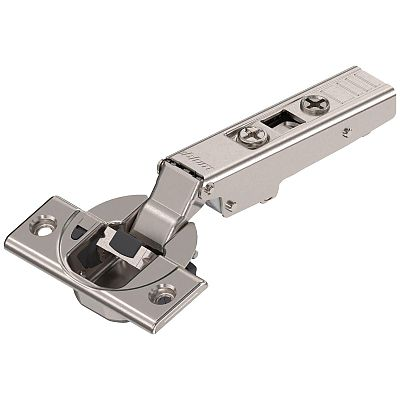

--- Highest capacity (18.0kg) ---



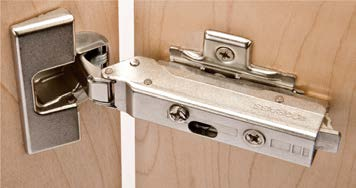
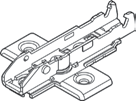

In [ ]:
# Find all valid configs for a standard full-overlay requirement (no brand preference)
open_req = CustomerRequirements(
    cabinet_type=CabinetType.FRAMELESS, door_thickness_mm=19, door_height_mm=720,
    door_weight_kg=5.0, application=ApplicationType.FULL_OVERLAY, desired_overlay_mm=16,
    boring_pattern_mm=45, soft_close=False,
)

all_valid = engine.solve(open_req)

def fmt_price(p):
    return f"${p:>9.2f}" if p is not None else "      N/A"

print(f"Found {len(all_valid)} valid configurations for standard full-overlay frameless\n")
print(f"{'Hinge SKU':<22} {'Plate SKU':<22} {'Brand':<8} {'Hinges':>6} {'Capacity':>10} {'Price/Door':>11}")
print("-" * 80)
for config in all_valid:
    print(f"{config.hinge.sku:<22} {config.plate.sku:<22} {config.hinge.brand:<8} "
          f"{config.hinges_per_door:>6} {config.total_weight_capacity_kg:>8.1f}kg "
          f"{fmt_price(config.total_price_usd)}")

# Show images for the cheapest and most capable options
priced = [c for c in all_valid if c.total_price_usd is not None]
if priced:
    print(f"\n--- Best value (cheapest) ---")
    show_product_images(priced[0].hinge.sku, priced[0].plate.sku)
if all_valid:
    most_capable = max(all_valid, key=lambda c: c.total_weight_capacity_kg)
    print(f"--- Highest capacity ({most_capable.total_weight_capacity_kg}kg) ---")
    show_product_images(most_capable.hinge.sku, most_capable.plate.sku)

## 7. Failure Analysis — Why Scenario 5 Has No Solution

When the engine can't find a valid configuration, it doesn't just say "no results." It finds the **closest match** — the hinge + plate pair that passes the most rules — and reports exactly which rules failed and why.

This is critical for the conversational layer. Instead of a dead end, the system can explain: "Your 12kg door is too heavy for any wide-angle hinge in the catalog. The closest option supports 10kg. Consider a lighter door material, or switch to a standard (non-corner) cabinet position which allows 110° hinges with higher weight ratings."

Scenario 5 is a deliberately impossible requirement: a heavy 12kg door on a corner cabinet with a Blum-only preference. The corner position forces a >=155° hinge (R013), but the only Blum 155° hinge is rated at 5kg — even with 2 hinges, that's only 10kg capacity vs the 12kg door (R007 fails). The engine's `_best_failing()` method identifies this and surfaces the specific constraint violations.

In [ ]:
# Scenario 5: heavy corner door — let's see exactly why it fails
title, req, result = all_results[4]
print(f"{title}\n")
print(f"Requirements:")
print(f"  Cabinet: {req.cabinet_type.value}, Position: {req.cabinet_position.value}")
print(f"  Door: {req.door_thickness_mm}mm thick, {req.door_height_mm}mm tall, {req.door_weight_kg}kg")
print(f"  Application: {req.application.value}, Overlay: {req.desired_overlay_mm}mm")
print(f"  Soft-close: {req.soft_close}, Brand: {req.preferred_brand}")
print()

print(f"Result: {result['status']}")
print(f"{result['message']}\n")

if result.get("closest_match"):
    cm = result["closest_match"]
    print(f"Closest match: {cm['hinge']['sku']} + {cm['mounting_plate']['sku']}")
    print(f"  {cm['hinge']['description']}")
    print(f"  Capacity: {cm['total_weight_capacity_kg']}kg for {cm['hinges_per_door']} hinges")
    print()

if result.get("failed_rules"):
    print("Failed constraints:")
    for fr in result["failed_rules"]:
        print(f"  [{fr['rule']}] {fr['name']}")
        print(f"    {fr['detail']}")

# Show the math behind the weight/angle analysis
num_h = engine.hinges_per_door(req.door_height_mm)
print(f"\n--- Analysis ---")
print(f"Corner cabinet requires >= 155\u00b0 hinge (R013)")
print(f"Door height {req.door_height_mm}mm -> {num_h} hinges (R008)")
print(f"Note: production engine does NOT apply R010 derating")
print(f"Blum 155\u00b0 hinge: 5.0kg max x {num_h} hinges = {5.0 * num_h}kg capacity")
print(f"Door weight: {req.door_weight_kg}kg -> {'FAIL' if req.door_weight_kg > 5.0 * num_h else 'PASS'}")

Scenario 5: CONSTRAINT VIOLATION — heavy corner door

Requirements:
  Cabinet: frameless, Position: corner
  Door: 22.0mm thick, 900.0mm tall, 12.0kg
  Application: full_overlay, Overlay: 16.0mm
  Soft-close: True, Brand: Blum

Result: solved
Found 33 valid configuration(s).


--- Analysis ---
Corner cabinet requires >= 155° hinge (R013)
Door height 900.0mm -> 3 hinges (R008)
Note: production engine does NOT apply R010 derating
Blum 155° hinge: 5.0kg max x 3 hinges = 15.0kg capacity
Door weight: 12.0kg -> PASS


## 8. Interactive Explorer

Modify the `CustomerRequirements` below and re-run the cell to test your own scenarios. The engine will return the best configuration or explain why none exists.

**Things to try:**
- Change `cabinet_position` to `CabinetPosition.CORNER` and watch the available options narrow to wide-angle hinges only
- Set `preferred_brand="Hafele"` to see limited options (thin catalog data for Hafele Duomatic)
- Increase `door_weight_kg` to 15+ and see which brands still have enough capacity
- Switch `application` to `ApplicationType.INSET` — only plates that support inset will match
- Set `has_adjacent_door=True` with `adjacent_door_overlay_mm=10` and `partition_thickness_mm=19` to trigger the adjacent door clearance check (R012)
- Try `cabinet_type=CabinetType.FACE_FRAME` with `face_frame_width_mm=38` for face-frame-specific constraints

In [ ]:
# === MODIFY THESE VALUES TO TEST YOUR OWN SCENARIOS ===

my_requirements = CustomerRequirements(
    cabinet_type=CabinetType.FRAMELESS,           # FRAMELESS or FACE_FRAME
    door_thickness_mm=19,                          # typical: 16-24mm
    door_height_mm=720,                            # mm (affects hinge count)
    door_weight_kg=5.0,                            # kg
    application=ApplicationType.FULL_OVERLAY,      # FULL_OVERLAY, HALF_OVERLAY, INSET, OVERLAY
    desired_overlay_mm=16,                         # mm
    drilling_distance_mm=5.0,                      # mm (NEW — for exact overlay calc)
    boring_pattern_mm=45,                          # mm (standard: 45)
    soft_close=True,                               # True or False
    cabinet_position=CabinetPosition.STANDARD,     # STANDARD, CORNER, BLIND_CORNER
    preferred_brand=None,                          # "Blum", "Grass", "Hafele", or None
    has_adjacent_door=False,                       # True if sharing a partition
    adjacent_door_overlay_mm=0,                    # mm (only if has_adjacent_door)
    partition_thickness_mm=19,                     # mm (only if has_adjacent_door)
    face_frame_width_mm=0,                         # mm (only if FACE_FRAME cabinet)
)

# === RUN THE ENGINE ===

result = engine.solve_with_explanation(my_requirements)

print(f"Status: {result['status']}")
print(f"{result['message']}\n")

if result["status"] == "solved":
    rec = result["recommended"]
    print(f"Recommended configuration:")
    print(f"  Hinge: {rec['hinge']['sku']} — {rec['hinge']['description']}")
    print(f"  Plate: {rec['mounting_plate']['sku']} — {rec['mounting_plate']['description']}")
    print(f"  Hinges per door: {rec['hinges_per_door']}")
    print(f"  Weight capacity: {rec['total_weight_capacity_kg']}kg")
    price = f"${rec['total_price_per_door_usd']}" if rec['total_price_per_door_usd'] is not None else "N/A"
    print(f"  Price per door: {price}")
    show_product_images(rec['hinge']['sku'], rec['mounting_plate']['sku'], width=250)
    print(f"\n  Constraint trace:")
    for rule in rec["constraint_trace"]:
        icon = "PASS" if rule["passed"] else "FAIL"
        print(f"    [{icon}] {rule['rule']} {rule['name']}: {rule['detail']}")
    
    if result["alternatives"]:
        print(f"\n  Alternatives ({len(result['alternatives'])}):")
        for alt in result["alternatives"]:
            alt_price = f"${alt['total_price_per_door_usd']}" if alt['total_price_per_door_usd'] is not None else "N/A"
            print(f"    {alt['hinge']['sku']} + {alt['mounting_plate']['sku']} — {alt_price}/door")

elif result["status"] == "no_solution":
    if result.get("closest_match"):
        cm = result["closest_match"]
        print(f"Closest match: {cm['hinge']['sku']} + {cm['mounting_plate']['sku']}")
    print(f"\nFailed rules:")
    for fr in result["failed_rules"]:
        print(f"  [{fr['rule']}] {fr['name']}: {fr['detail']}")

elif result["status"] == "no_solution_for_brand":
    for alt in result["alternatives"]:
        alt_price = f"${alt['total_price_per_door_usd']}" if alt['total_price_per_door_usd'] is not None else "N/A"
        print(f"  {alt['hinge']['sku']} — {alt['hinge']['description']} ({alt_price}/door)")
        show_product_images(alt['hinge']['sku'], alt['mounting_plate']['sku'], width=180)

Status: solved
Found 123 valid configuration(s).

Recommended configuration:
  Hinge: HFL-311131 — Hafele Duomatic 110° full_overlay
  Plate: HFL-311971 — Hafele Duomatic cruciform 0.0mm
  Hinges per door: 2
  Weight capacity: 12.0kg
  Price per door: $10.6

  Constraint trace:
    [PASS] R001 brand_lock: Hinge brand 'Hafele' == plate brand 'Hafele'
    [PASS] R002 series_compatibility: Hinge series 'Duomatic' in plate compatible series ['Duomatic']
    [PASS] R003 cabinet_type_match: Cabinet type: hinge=frameless, plate=frameless, required=frameless
    [PASS] R004 overlay_in_range: Desired overlay 16.0mm vs plate range [14.0-19.0]mm for full_overlay
    [PASS] R005 inset_support: Not an inset application — skipped
    [PASS] R006 door_thickness_range: Door 19.0mm vs hinge range [16.0-22.0]mm
    [PASS] R007 door_weight_limit: Door 5.0kg vs capacity 6.0kg x 2 = 12.0kg
    [PASS] R009 boring_pattern_match: Hinge boring 45mm vs required 45mm
    [PASS] R013 corner_cabinet_angle: Not a c